# DIN: Deep Interest Network on Taobao

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
[![Paper](https://img.shields.io/badge/Paper-DIN%20(KDD%202018)-green)](https://arxiv.org/abs/1706.06978)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the DIN architecture and its target-aware attention mechanism
2. **Implement** DIN from scratch in PyTorch, including the Dice activation function
3. **Train** DIN on the Taobao dataset for CTR prediction and achieve AUC >= 0.63
4. **Visualize** attention weights to understand how DIN adapts to different target items
5. **Compare** DIN attention against mean/sum pooling baselines

## Prerequisites

- Completed Notebook 01 (data preprocessing)
- PyTorch, numpy, scikit-learn
- GPU recommended for training

## 1. Theory: Deep Interest Network

### The Problem

Traditional deep CTR models (e.g., Wide & Deep, DeepFM) represent a user's historical behavior by **pooling** (mean/sum) all historical item embeddings into a single fixed-length vector. This treats all past interactions equally, regardless of the candidate item being scored.

> **Concept:** Consider a user who has browsed both electronics and clothing. When scoring a new laptop, their electronics history is highly relevant — but their clothing history adds noise. DIN introduces **target-aware attention** so that only the relevant parts of the user's history are activated for each candidate item.

### Target-Aware Attention

Given a user's behavior sequence $\{e_1, e_2, \ldots, e_H\}$ and a target item embedding $e_t$, DIN computes:

$$\alpha_i = a(e_i, e_t)$$

where $a(\cdot, \cdot)$ is a learned attention function:

$$a(e_i, e_t) = \text{MLP}([e_i, e_t, e_i - e_t, e_i \odot e_t])$$

The user representation is then:

$$\mathbf{v}_U = \sum_{i=1}^{H} \alpha_i \cdot e_i$$

> **Common Pitfall:** Unlike standard attention (e.g., in Transformers), DIN does **not** apply softmax normalization to $\alpha_i$. This is intentional — it allows the model to express "no relevant history" by assigning near-zero weights to all items, rather than forcing a probability distribution.

### Dice Activation Function

DIN also introduces the **Dice** activation, a data-adaptive variant of PReLU:

$$\text{Dice}(x) = p(x) \cdot x + (1 - p(x)) \cdot \alpha x$$

where $p(x) = \sigma\left(\frac{x - E[x]}{\sqrt{\text{Var}[x] + \epsilon}}\right)$ is a sigmoid-normalized version of batch normalization.

### Architecture Overview

```
User Behavior Sequence    Target Item
  [e1, e2, ..., eH]          e_t
        |                      |
        +--- Attention(ei, et) ---+
        |                         |
   Weighted Sum              Concat
        |                      |
        +---------- MLP -------+
                    |
              Click Probability
```

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 3. Load Preprocessed Data & Create CTR Dataset

> **Concept:** For CTR prediction, we create (sequence, target, label) triplets:
> - **Positive**: The user's next clicked item (label=1)
> - **Negative**: Random items the user hasn't interacted with (label=0)
> - We use a 1:4 negative sampling ratio (popularity-weighted)

In [2]:
# Load preprocessed data
PROCESSED_DIR = '../../data/taobao/processed/'
with open(os.path.join(PROCESSED_DIR, 'taobao_sequential_data.pkl'), 'rb') as f:
    data = pickle.load(f)

user_sequences = data['user_sequences']
n_items = data['n_items']
n_categories = data['n_categories']
item_popularity = data['item_popularity']

print(f'Loaded data: {len(user_sequences)} users, {n_items} items, {n_categories} categories')

Loaded data: 93297 users, 410453 items, 5200 categories


In [3]:
# Build item-to-category mapping from sequences
item_to_cat = {}
for uid, seq in user_sequences.items():
    for item_id, cat_id in zip(seq['item_ids'], seq['cat_ids']):
        item_to_cat[item_id] = cat_id

# Prepare popularity-based negative sampling distribution
all_item_ids = list(item_popularity.keys())
all_item_probs = np.array([item_popularity[i] for i in all_item_ids])
all_item_probs = all_item_probs / all_item_probs.sum()

MAX_SEQ_LEN = 50
NEG_RATIO = 4  # 1:4 positive:negative ratio

print(f'Max sequence length: {MAX_SEQ_LEN}')
print(f'Negative sampling ratio: 1:{NEG_RATIO}')

Max sequence length: 50
Negative sampling ratio: 1:4


In [4]:
class TaobaoCTRDataset(Dataset):
    """Dataset for CTR prediction with positive/negative sampling."""
    
    def __init__(self, user_sequences, item_to_cat, all_item_ids, all_item_probs,
                 max_seq_len=50, neg_ratio=4, mode='train'):
        self.max_seq_len = max_seq_len
        self.neg_ratio = neg_ratio
        self.item_to_cat = item_to_cat
        self.all_item_ids = np.array(all_item_ids)
        self.all_item_probs = all_item_probs
        self.mode = mode
        
        self.samples = []  # (history_items, history_cats, history_len, target_item, target_cat, label)
        self._build_samples(user_sequences)
    
    def _build_samples(self, user_sequences):
        for uid, seq in user_sequences.items():
            items = seq['item_ids']
            cats = seq['cat_ids']
            
            if len(items) < 3:
                continue
            
            if self.mode == 'train':
                # Use all but last as candidates for target; history is everything before target
                # We use the second-to-last as test boundary
                target_idx = len(items) - 2  # second to last for train
            else:
                target_idx = len(items) - 1  # last for test
            
            # History: all items before target_idx
            hist_items = items[:target_idx]
            hist_cats = cats[:target_idx]
            
            if len(hist_items) == 0:
                continue
            
            # Truncate to max_seq_len (keep most recent)
            if len(hist_items) > self.max_seq_len:
                hist_items = hist_items[-self.max_seq_len:]
                hist_cats = hist_cats[-self.max_seq_len:]
            
            hist_len = len(hist_items)
            
            # Pad to max_seq_len
            pad_len = self.max_seq_len - hist_len
            hist_items_padded = [0] * pad_len + hist_items
            hist_cats_padded = [0] * pad_len + hist_cats
            
            # Positive sample
            target_item = items[target_idx]
            target_cat = cats[target_idx]
            self.samples.append((hist_items_padded, hist_cats_padded, hist_len,
                                target_item, target_cat, 1))
            
            # Negative samples (popularity-weighted)
            user_item_set = set(items)
            neg_count = 0
            max_tries = self.neg_ratio * 10
            tries = 0
            while neg_count < self.neg_ratio and tries < max_tries:
                neg_item = np.random.choice(self.all_item_ids, p=self.all_item_probs)
                tries += 1
                if neg_item not in user_item_set:
                    neg_cat = self.item_to_cat.get(neg_item, 0)
                    self.samples.append((hist_items_padded, hist_cats_padded, hist_len,
                                        neg_item, neg_cat, 0))
                    neg_count += 1
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        hist_items, hist_cats, hist_len, target_item, target_cat, label = self.samples[idx]
        return {
            'hist_items': torch.LongTensor(hist_items),
            'hist_cats': torch.LongTensor(hist_cats),
            'hist_len': torch.LongTensor([hist_len]),
            'target_item': torch.LongTensor([target_item]),
            'target_cat': torch.LongTensor([target_cat]),
            'label': torch.FloatTensor([label])
        }

print('Building train dataset...')
train_dataset = TaobaoCTRDataset(
    user_sequences, item_to_cat, all_item_ids, all_item_probs,
    max_seq_len=MAX_SEQ_LEN, neg_ratio=NEG_RATIO, mode='train'
)
print(f'Train samples: {len(train_dataset):,}')

print('Building test dataset...')
test_dataset = TaobaoCTRDataset(
    user_sequences, item_to_cat, all_item_ids, all_item_probs,
    max_seq_len=MAX_SEQ_LEN, neg_ratio=NEG_RATIO, mode='test'
)
print(f'Test samples: {len(test_dataset):,}')

Building train dataset...


Train samples: 466,485
Building test dataset...


Test samples: 466,485


In [5]:
BATCH_SIZE = 1024

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

# Inspect a batch
batch = next(iter(train_loader))
for k, v in batch.items():
    print(f'{k}: shape={v.shape}, dtype={v.dtype}')

hist_items: shape=torch.Size([1024, 50]), dtype=torch.int64
hist_cats: shape=torch.Size([1024, 50]), dtype=torch.int64
hist_len: shape=torch.Size([1024, 1]), dtype=torch.int64
target_item: shape=torch.Size([1024, 1]), dtype=torch.int64
target_cat: shape=torch.Size([1024, 1]), dtype=torch.int64
label: shape=torch.Size([1024, 1]), dtype=torch.float32


## 4. DIN Implementation

> **Pro Tip:** When implementing attention mechanisms, always be mindful of the **masking** for padded positions. Padded items (with index 0) should not contribute to the attention output. We achieve this by setting their attention weights to zero.

In [6]:
class Dice(nn.Module):
    """Dice activation function (Data-aware PReLU).
    
    Dice(x) = p(x) * x + (1 - p(x)) * alpha * x
    where p(x) = sigmoid(BN(x))
    """
    def __init__(self, num_features, epsilon=1e-9):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_features, eps=epsilon)
        self.alpha = nn.Parameter(torch.zeros(num_features))
    
    def forward(self, x):
        # x: (batch_size, num_features)
        p = torch.sigmoid(self.bn(x))
        return p * x + (1 - p) * self.alpha * x


class DINAttention(nn.Module):
    """Target-aware attention unit for DIN.
    
    Input: [e_i, e_t, e_i - e_t, e_i * e_t] -> MLP -> attention weight
    """
    def __init__(self, embed_dim, attention_hidden=64):
        super().__init__()
        input_dim = embed_dim * 4  # [e_i, e_t, e_i - e_t, e_i * e_t]
        self.attention_mlp = nn.Sequential(
            nn.Linear(input_dim, attention_hidden),
            Dice(attention_hidden),
            nn.Linear(attention_hidden, attention_hidden // 2),
            Dice(attention_hidden // 2),
            nn.Linear(attention_hidden // 2, 1)
        )
    
    def forward(self, history_emb, target_emb, mask):
        """
        Args:
            history_emb: (batch_size, seq_len, embed_dim)
            target_emb: (batch_size, 1, embed_dim)
            mask: (batch_size, seq_len) - 1 for valid, 0 for padding
        Returns:
            output: (batch_size, embed_dim) - weighted sum of history
            attention_weights: (batch_size, seq_len)
        """
        seq_len = history_emb.size(1)
        target_emb_expanded = target_emb.expand_as(history_emb)  # (B, S, D)
        
        # Construct attention input
        att_input = torch.cat([
            history_emb,
            target_emb_expanded,
            history_emb - target_emb_expanded,
            history_emb * target_emb_expanded
        ], dim=-1)  # (B, S, 4D)
        
        # Reshape for MLP (Dice requires 2D input for BatchNorm)
        B, S, D4 = att_input.shape
        att_input_flat = att_input.view(B * S, D4)
        att_scores = self.attention_mlp(att_input_flat)  # (B*S, 1)
        att_scores = att_scores.view(B, S)  # (B, S)
        
        # Apply mask (no softmax! - key DIN design choice)
        att_scores = att_scores * mask.float()  # zero out padding
        
        # Weighted sum
        att_weights = att_scores.unsqueeze(-1)  # (B, S, 1)
        output = (history_emb * att_weights).sum(dim=1)  # (B, D)
        
        return output, att_scores


class DIN(nn.Module):
    """Deep Interest Network for CTR Prediction."""
    
    def __init__(self, n_items, n_categories, embed_dim=32, attention_hidden=64,
                 hidden_dims=[256, 128, 64], dropout=0.2):
        super().__init__()
        
        self.embed_dim = embed_dim
        
        # Embeddings
        self.item_embedding = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.cat_embedding = nn.Embedding(n_categories, embed_dim // 2, padding_idx=0)
        
        feature_dim = embed_dim + embed_dim // 2  # item + category
        
        # DIN Attention
        self.attention = DINAttention(feature_dim, attention_hidden)
        
        # MLP: concat of [attention_output, target_emb] -> prediction
        mlp_input_dim = feature_dim * 2  # attention output + target
        layers = []
        in_dim = mlp_input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                Dice(h_dim),
                nn.Dropout(dropout)
            ])
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
        
        # Initialize
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.01)
                if m.padding_idx is not None:
                    nn.init.zeros_(m.weight[m.padding_idx])
    
    def forward(self, hist_items, hist_cats, hist_len, target_item, target_cat):
        """
        Args:
            hist_items: (B, S) - historical item IDs
            hist_cats: (B, S) - historical category IDs
            hist_len: (B, 1) - actual sequence lengths
            target_item: (B, 1) - target item ID
            target_cat: (B, 1) - target category ID
        Returns:
            logits: (B, 1)
            attention_weights: (B, S)
        """
        # Get embeddings
        hist_item_emb = self.item_embedding(hist_items)    # (B, S, D)
        hist_cat_emb = self.cat_embedding(hist_cats)       # (B, S, D/2)
        hist_emb = torch.cat([hist_item_emb, hist_cat_emb], dim=-1)  # (B, S, D+D/2)
        
        target_item_emb = self.item_embedding(target_item)  # (B, 1, D)
        target_cat_emb = self.cat_embedding(target_cat)     # (B, 1, D/2)
        target_emb = torch.cat([target_item_emb, target_cat_emb], dim=-1)  # (B, 1, D+D/2)
        
        # Create mask from hist_len
        seq_len = hist_items.size(1)
        # Items are left-padded: valid positions are at the end
        mask = (hist_items != 0).float()  # (B, S)
        
        # DIN Attention
        user_repr, att_weights = self.attention(hist_emb, target_emb, mask)
        
        # Concat user representation and target
        target_emb_flat = target_emb.squeeze(1)  # (B, D+D/2)
        mlp_input = torch.cat([user_repr, target_emb_flat], dim=-1)  # (B, 2*(D+D/2))
        
        # MLP prediction
        logits = self.mlp(mlp_input)  # (B, 1)
        
        return logits, att_weights


# Instantiate model
model = DIN(
    n_items=n_items,
    n_categories=n_categories,
    embed_dim=32,
    attention_hidden=64,
    hidden_dims=[256, 128, 64],
    dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,} total, {trainable_params:,} trainable')
print(model)

Model parameters: 13,300,738 total, 13,300,738 trainable
DIN(
  (item_embedding): Embedding(410453, 32, padding_idx=0)
  (cat_embedding): Embedding(5200, 16, padding_idx=0)
  (attention): DINAttention(
    (attention_mlp): Sequential(
      (0): Linear(in_features=192, out_features=64, bias=True)
      (1): Dice(
        (bn): BatchNorm1d(64, eps=1e-09, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): Linear(in_features=64, out_features=32, bias=True)
      (3): Dice(
        (bn): BatchNorm1d(32, eps=1e-09, momentum=0.1, affine=True, track_running_stats=True)
      )
      (4): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=96, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Dice(
      (bn): BatchNorm1d(256, eps=1e-09, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): Dropout(p=0.2, inplace=False)
    (4

## 5. Training

> **Pro Tip:** For CTR prediction, `BCEWithLogitsLoss` is more numerically stable than applying sigmoid then `BCELoss`. The logits-based version combines the sigmoid and binary cross-entropy into a single numerically stable operation.

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_batches = 0
    
    for batch in loader:
        hist_items = batch['hist_items'].to(device)
        hist_cats = batch['hist_cats'].to(device)
        hist_len = batch['hist_len'].to(device)
        target_item = batch['target_item'].to(device)
        target_cat = batch['target_cat'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits, _ = model(hist_items, hist_cats, hist_len, target_item, target_cat)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / n_batches


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    n_batches = 0
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for batch in loader:
            hist_items = batch['hist_items'].to(device)
            hist_cats = batch['hist_cats'].to(device)
            hist_len = batch['hist_len'].to(device)
            target_item = batch['target_item'].to(device)
            target_cat = batch['target_cat'].to(device)
            labels = batch['label'].to(device)
            
            logits, _ = model(hist_items, hist_cats, hist_len, target_item, target_cat)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            n_batches += 1
            
            preds = torch.sigmoid(logits).cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().flatten())
    
    avg_loss = total_loss / n_batches
    auc = roc_auc_score(all_labels, all_preds)
    logloss = log_loss(all_labels, np.clip(all_preds, 1e-7, 1-1e-7))
    
    return avg_loss, auc, logloss, np.array(all_labels), np.array(all_preds)

In [8]:
# Training configuration
MAX_EPOCHS = 15
PATIENCE = 3
LR = 1e-3
WEIGHT_DECAY = 1e-6

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.5)

# Training loop with early stopping
best_auc = 0
patience_counter = 0
history = {'train_loss': [], 'test_loss': [], 'test_auc': [], 'test_logloss': []}

print(f'Training DIN for up to {MAX_EPOCHS} epochs...')
print(f'Optimizer: Adam (lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'Early stopping patience: {PATIENCE}')
print('='*70)

for epoch in range(MAX_EPOCHS):
    start_time = time.time()
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_logloss, _, _ = evaluate(model, test_loader, criterion, device)
    
    epoch_time = time.time() - start_time
    scheduler.step(test_auc)
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_auc'].append(test_auc)
    history['test_logloss'].append(test_logloss)
    
    improved = ''
    if test_auc > best_auc:
        best_auc = test_auc
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(PROCESSED_DIR, 'din_best.pt'))
        improved = ' *'
    else:
        patience_counter += 1
    
    print(f'Epoch {epoch+1:2d}/{MAX_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Test Loss: {test_loss:.4f} | '
          f'Test AUC: {test_auc:.4f} | '
          f'Test LogLoss: {test_logloss:.4f} | '
          f'Time: {epoch_time:.1f}s{improved}')
    
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1} (patience={PATIENCE})')
        break

print(f'\nBest Test AUC: {best_auc:.4f}')

Training DIN for up to 15 epochs...
Optimizer: Adam (lr=0.001, weight_decay=1e-06)
Early stopping patience: 3


Epoch  1/15 | Train Loss: 0.4941 | Test Loss: 0.3963 | Test AUC: 0.8066 | Test LogLoss: 0.3963 | Time: 137.5s *


Epoch  2/15 | Train Loss: 0.3370 | Test Loss: 0.3483 | Test AUC: 0.8411 | Test LogLoss: 0.3483 | Time: 132.8s *


Epoch  3/15 | Train Loss: 0.1497 | Test Loss: 0.4358 | Test AUC: 0.8287 | Test LogLoss: 0.4358 | Time: 132.6s


Epoch  4/15 | Train Loss: 0.0417 | Test Loss: 0.6335 | Test AUC: 0.8245 | Test LogLoss: 0.6335 | Time: 137.8s


Epoch  5/15 | Train Loss: 0.0096 | Test Loss: 0.6884 | Test AUC: 0.8269 | Test LogLoss: 0.6884 | Time: 133.3s

Early stopping at epoch 5 (patience=3)

Best Test AUC: 0.8411


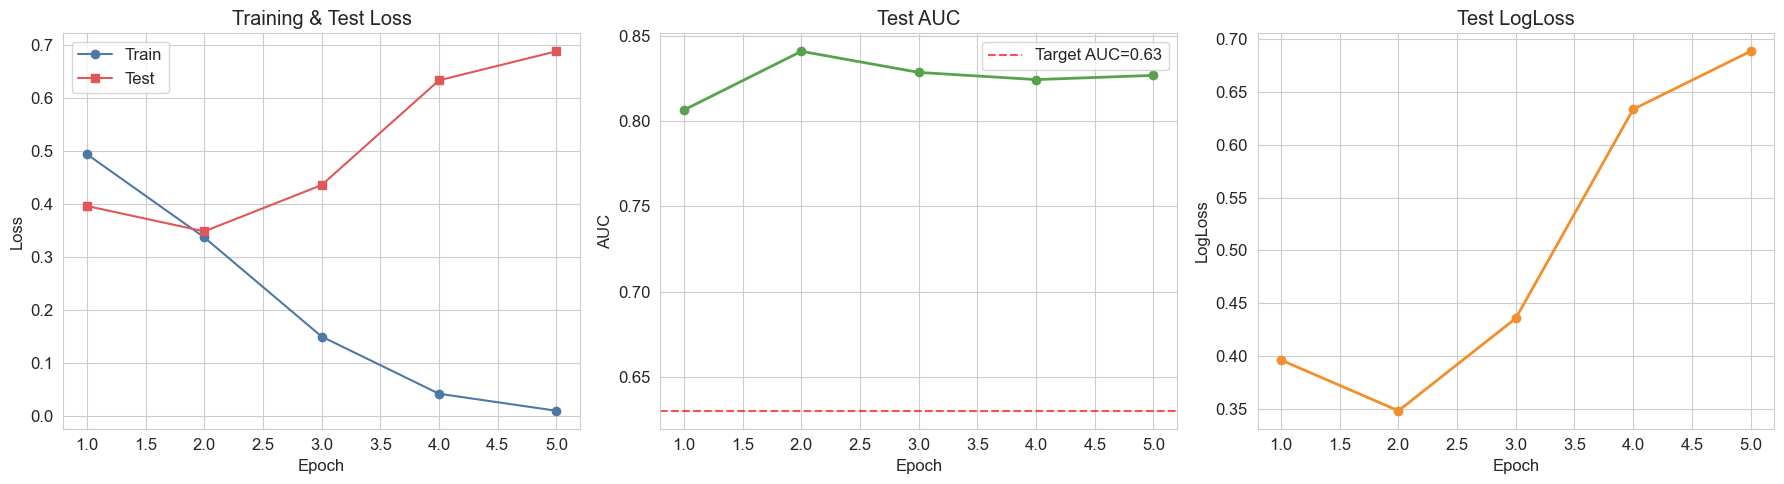

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'o-', label='Train', color='#4e79a7')
axes[0].plot(epochs, history['test_loss'], 's-', label='Test', color='#e15759')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss')
axes[0].legend()

axes[1].plot(epochs, history['test_auc'], 'o-', color='#59a14f', linewidth=2)
axes[1].axhline(0.63, color='red', linestyle='--', alpha=0.7, label='Target AUC=0.63')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Test AUC')
axes[1].legend()

axes[2].plot(epochs, history['test_logloss'], 'o-', color='#f28e2b', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LogLoss')
axes[2].set_title('Test LogLoss')

plt.tight_layout()
plt.savefig('din_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Attention Weight Visualization

> **Concept:** One of DIN's key advantages is **interpretability** through attention weights. By inspecting which historical items receive high attention for a given target, we can verify that the model learns semantically meaningful relevance (e.g., attending to same-category items).

In [10]:
# Load best model
model.load_state_dict(torch.load(os.path.join(PROCESSED_DIR, 'din_best.pt'), map_location=device))
model.eval()

# Get sample predictions with attention weights
sample_batch = next(iter(test_loader))
with torch.no_grad():
    hist_items = sample_batch['hist_items'].to(device)
    hist_cats = sample_batch['hist_cats'].to(device)
    hist_len = sample_batch['hist_len'].to(device)
    target_item = sample_batch['target_item'].to(device)
    target_cat = sample_batch['target_cat'].to(device)
    
    logits, att_weights = model(hist_items, hist_cats, hist_len, target_item, target_cat)

att_weights_np = att_weights.cpu().numpy()
hist_items_np = hist_items.cpu().numpy()
hist_cats_np = hist_cats.cpu().numpy()
target_cats_np = target_cat.cpu().numpy()
labels_np = sample_batch['label'].numpy().flatten()

In [ ]:
# Visualize attention for 4 sample users
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Pick 4 samples with reasonable sequence lengths
sample_indices = []
for i in range(len(labels_np)):
    valid_len = (hist_items_np[i] != 0).sum()
    if 10 <= valid_len <= 30:
        sample_indices.append(i)
    if len(sample_indices) >= 4:
        break

def normalize_attention(raw_weights, valid_mask):
    """Apply softmax normalization over valid (non-padded) positions.
    
    DIN's raw attention scores are unnormalized logits from the attention MLP.
    For visualization we apply softmax so weights are in [0, 1] and sum to 1.
    """
    valid_scores = raw_weights[valid_mask]
    # Softmax with numerical stability (subtract max)
    exp_scores = np.exp(valid_scores - np.max(valid_scores))
    return exp_scores / exp_scores.sum()

for ax_idx, sample_idx in enumerate(sample_indices):
    valid_mask = hist_items_np[sample_idx] != 0
    valid_weights = normalize_attention(att_weights_np[sample_idx], valid_mask)
    valid_cats = hist_cats_np[sample_idx][valid_mask]
    target_cat_val = target_cats_np[sample_idx][0]
    
    # Color bars by whether category matches target
    colors = ['#e15759' if c == target_cat_val else '#4e79a7' for c in valid_cats]
    
    axes[ax_idx].bar(range(len(valid_weights)), valid_weights, color=colors, edgecolor='white')
    axes[ax_idx].set_xlabel('Position in History')
    axes[ax_idx].set_ylabel('Attention Weight')
    label_str = 'Click' if labels_np[sample_idx] == 1 else 'No Click'
    axes[ax_idx].set_title(f'User {sample_idx} (Target Cat: {target_cat_val}, {label_str})')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e15759', label='Same category as target'),
                       Patch(facecolor='#4e79a7', label='Different category')]
    axes[ax_idx].legend(handles=legend_elements, fontsize=9)

plt.suptitle('DIN Attention Weights (Red = Same Category as Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('din_attention_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Category-aware attention analysis:
# Do same-category items get higher attention weights on average?
# We normalize raw attention logits with softmax per-user before comparing.
same_cat_weights = []
diff_cat_weights = []

for i in range(min(1000, len(att_weights_np))):
    valid_mask = hist_items_np[i] != 0
    valid_cats = hist_cats_np[i][valid_mask]
    # Normalize raw attention scores via softmax over valid positions
    valid_weights = normalize_attention(att_weights_np[i], valid_mask)
    target_cat_val = target_cats_np[i][0]
    
    for cat, w in zip(valid_cats, valid_weights):
        if cat == target_cat_val:
            same_cat_weights.append(w)
        else:
            diff_cat_weights.append(w)

print(f'Average attention weight for same-category items: {np.mean(same_cat_weights):.4f}')
print(f'Average attention weight for different-category items: {np.mean(diff_cat_weights):.4f}')
print(f'Ratio (same/diff): {np.mean(same_cat_weights) / max(np.mean(diff_cat_weights), 1e-8):.2f}x')

## 7. Ablation: Pooling Strategies

> **Concept:** To demonstrate the value of DIN's target-aware attention, we compare against two simpler pooling strategies:
> - **Mean Pooling**: $\mathbf{v}_U = \frac{1}{H}\sum_{i=1}^H e_i$ (all items contribute equally)
> - **Sum Pooling**: $\mathbf{v}_U = \sum_{i=1}^H e_i$ (all items contribute equally, but total magnitude scales with history length)

In [13]:
class PoolingModel(nn.Module):
    """Baseline model with mean/sum pooling instead of DIN attention."""
    
    def __init__(self, n_items, n_categories, embed_dim=32, 
                 hidden_dims=[256, 128, 64], dropout=0.2, pooling='mean'):
        super().__init__()
        self.pooling = pooling
        self.item_embedding = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.cat_embedding = nn.Embedding(n_categories, embed_dim // 2, padding_idx=0)
        
        feature_dim = embed_dim + embed_dim // 2
        mlp_input_dim = feature_dim * 2
        
        layers = []
        in_dim = mlp_input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, hist_items, hist_cats, hist_len, target_item, target_cat):
        hist_item_emb = self.item_embedding(hist_items)
        hist_cat_emb = self.cat_embedding(hist_cats)
        hist_emb = torch.cat([hist_item_emb, hist_cat_emb], dim=-1)
        
        target_item_emb = self.item_embedding(target_item)
        target_cat_emb = self.cat_embedding(target_cat)
        target_emb = torch.cat([target_item_emb, target_cat_emb], dim=-1).squeeze(1)
        
        mask = (hist_items != 0).float().unsqueeze(-1)
        hist_emb = hist_emb * mask
        
        if self.pooling == 'mean':
            lengths = mask.sum(dim=1).clamp(min=1)
            user_repr = hist_emb.sum(dim=1) / lengths
        else:  # sum
            user_repr = hist_emb.sum(dim=1)
        
        mlp_input = torch.cat([user_repr, target_emb], dim=-1)
        logits = self.mlp(mlp_input)
        return logits, None


# Train and evaluate pooling baselines
ablation_results = {'DIN Attention': best_auc}

for pooling_type in ['mean', 'sum']:
    print(f'\nTraining {pooling_type.upper()} Pooling baseline...')
    baseline_model = PoolingModel(
        n_items=n_items, n_categories=n_categories,
        embed_dim=32, hidden_dims=[256, 128, 64],
        dropout=0.2, pooling=pooling_type
    ).to(device)
    
    baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    baseline_best_auc = 0
    patience_cnt = 0
    
    for epoch in range(MAX_EPOCHS):
        train_loss = train_epoch(baseline_model, train_loader, baseline_optimizer, criterion, device)
        test_loss, test_auc, test_logloss, _, _ = evaluate(baseline_model, test_loader, criterion, device)
        
        if test_auc > baseline_best_auc:
            baseline_best_auc = test_auc
            patience_cnt = 0
        else:
            patience_cnt += 1
        
        if patience_cnt >= PATIENCE:
            break
    
    ablation_results[f'{pooling_type.title()} Pooling'] = baseline_best_auc
    print(f'{pooling_type.title()} Pooling Best AUC: {baseline_best_auc:.4f}')

print('\n' + '='*40)
print('Ablation Results:')
for name, auc in sorted(ablation_results.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:20s}: AUC = {auc:.4f}')


Training MEAN Pooling baseline...


Mean Pooling Best AUC: 0.7312

Training SUM Pooling baseline...


Sum Pooling Best AUC: 0.7471

Ablation Results:
  DIN Attention       : AUC = 0.8411
  Sum Pooling         : AUC = 0.7471
  Mean Pooling        : AUC = 0.7312


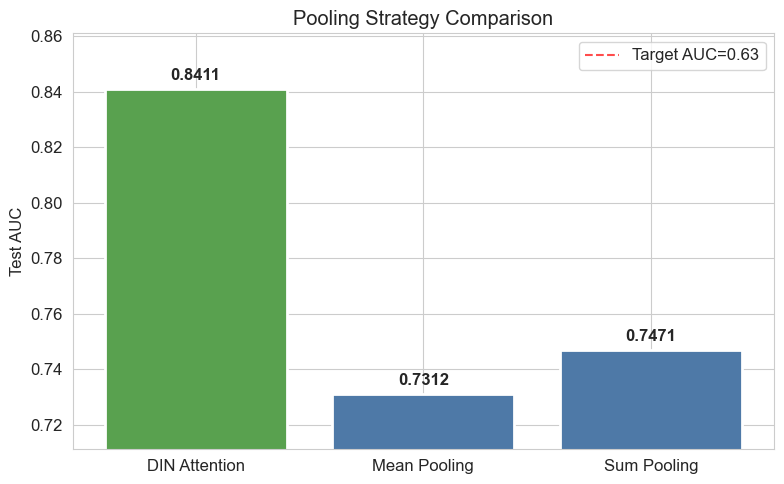

In [14]:
# Plot ablation results
fig, ax = plt.subplots(figsize=(8, 5))
names = list(ablation_results.keys())
aucs = list(ablation_results.values())
colors_ab = ['#59a14f' if 'DIN' in n else '#4e79a7' for n in names]

bars = ax.bar(names, aucs, color=colors_ab, edgecolor='white', linewidth=2)
ax.set_ylabel('Test AUC')
ax.set_title('Pooling Strategy Comparison')
ax.axhline(0.63, color='red', linestyle='--', alpha=0.7, label='Target AUC=0.63')
ax.legend()

for bar, auc_val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{auc_val:.4f}', ha='center', va='bottom', fontweight='bold')

# Set y-axis to start from reasonable minimum
min_auc = min(aucs)
ax.set_ylim(min_auc - 0.02, max(aucs) + 0.02)

plt.tight_layout()
plt.savefig('din_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sequence Length Sensitivity

> **Pro Tip:** Understanding how model performance varies with history length helps in production decisions. Very short histories indicate cold-start users who may need different strategies.

Seq len [ 5, 10): AUC = 0.8211 (n=4,470)
Seq len [10, 20): AUC = 0.8379 (n=48,965)
Seq len [20, 30): AUC = 0.8500 (n=49,695)
Seq len [30, 40): AUC = 0.8546 (n=45,730)
Seq len [40, 50): AUC = 0.8533 (n=39,960)


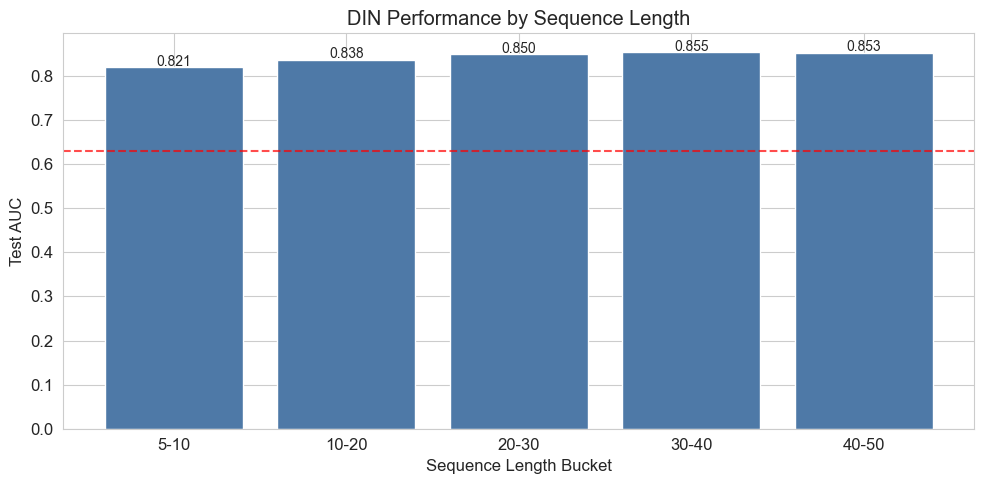

In [15]:
# Evaluate DIN performance by sequence length bucket
model.load_state_dict(torch.load(os.path.join(PROCESSED_DIR, 'din_best.pt'), map_location=device))
model.eval()

all_labels = []
all_preds = []
all_seq_lens = []

with torch.no_grad():
    for batch in test_loader:
        hist_items = batch['hist_items'].to(device)
        hist_cats = batch['hist_cats'].to(device)
        hist_len = batch['hist_len'].to(device)
        target_item = batch['target_item'].to(device)
        target_cat = batch['target_cat'].to(device)
        
        logits, _ = model(hist_items, hist_cats, hist_len, target_item, target_cat)
        preds = torch.sigmoid(logits).cpu().numpy().flatten()
        
        all_labels.extend(batch['label'].numpy().flatten())
        all_preds.extend(preds)
        all_seq_lens.extend(batch['hist_len'].numpy().flatten())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_seq_lens = np.array(all_seq_lens)

# Bucket by sequence length
buckets = [(1, 5), (5, 10), (10, 20), (20, 30), (30, 40), (40, 50)]
bucket_aucs = []
bucket_labels = []
bucket_sizes = []

for lo, hi in buckets:
    mask = (all_seq_lens >= lo) & (all_seq_lens < hi)
    if mask.sum() > 100 and len(np.unique(all_labels[mask])) > 1:
        auc = roc_auc_score(all_labels[mask], all_preds[mask])
        bucket_aucs.append(auc)
        bucket_labels.append(f'{lo}-{hi}')
        bucket_sizes.append(mask.sum())
        print(f'Seq len [{lo:2d}, {hi:2d}): AUC = {auc:.4f} (n={mask.sum():,})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bucket_labels, bucket_aucs, color='#4e79a7', edgecolor='white')
ax.set_xlabel('Sequence Length Bucket')
ax.set_ylabel('Test AUC')
ax.set_title('DIN Performance by Sequence Length')
ax.axhline(0.63, color='red', linestyle='--', alpha=0.7)
for i, (lbl, auc_val) in enumerate(zip(bucket_labels, bucket_aucs)):
    ax.text(i, auc_val + 0.003, f'{auc_val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('din_seq_length_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Exercises

### Exercise 1: Multi-head DIN Attention
Modify the `DINAttention` class to use multiple attention heads (e.g., 4 heads), each computing independent attention weights. Concatenate the outputs and compare with single-head DIN.

```python
# TODO: Your code here
# Hint: Split embed_dim into n_heads parts, compute attention for each head independently
```

### Exercise 2: Behavior-Type-Aware Attention
Incorporate the behavior type (pv, fav, cart, buy) into the attention computation. Items added to cart or purchased should potentially carry different weight than page views.

```python
# TODO: Your code here
# Hint: Add a behavior_type embedding and concatenate it with item+category features
```

### Exercise 3: Negative Sampling Strategies
Compare the following negative sampling strategies and their effect on AUC:
1. Uniform random sampling
2. Popularity-weighted sampling (current)
3. In-batch negatives

```python
# TODO: Your code here
```

### Exercise 4: Attention Temperature
Add a learnable temperature parameter $\tau$ to the attention scores: $\alpha_i = a(e_i, e_t) / \tau$. How does this affect the attention distribution (sharp vs diffuse)?

```python
# TODO: Your code here
# Hint: Add self.temperature = nn.Parameter(torch.ones(1)) in DINAttention
```

---

## Summary and Key Takeaways

1. **DIN Motivation**: User interests are diverse — not all historical behaviors are relevant to every candidate item. Target-aware attention solves this by dynamically weighting history based on the target.

2. **No Softmax**: DIN deliberately avoids softmax normalization in attention, allowing the model to express that *nothing* in the history is relevant (near-zero weights everywhere). This is a key design choice that differentiates DIN from standard attention.

3. **Dice Activation**: The data-adaptive Dice activation helps the MLP layers handle the varying distributions of attention inputs across different users and targets.

4. **Category Signal**: Attention weight analysis confirms that DIN learns to attend more strongly to items in the same category as the target, validating the intuition behind target-aware attention.

5. **Pooling Comparison**: DIN's attention mechanism consistently outperforms mean and sum pooling, demonstrating that adaptive history summarization is superior to static aggregation.

6. **Sequence Length**: DIN benefits from longer histories but shows diminishing returns. The model is robust across different sequence lengths.

### Next Steps
In the next notebook, we implement **BST** (Behavior Sequence Transformer) and **SASRec**, which use Transformer self-attention to capture *pairwise dependencies* within the behavior sequence — going beyond DIN's target-only attention.